<a href="https://colab.research.google.com/github/karthikeyan15-bit/NPL_project_repo/blob/main/NLP_lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd # data loading
import numpy as np # numpy is used for mathematical operations and we can use python list but numpy is fast and betterv in computation
import re  # regular expression clean the textual data
import nltk # for basic
import matplotlib.pyplot as plt # visualiazation
from nltk.corpus import stopwords # to remove be verbs unwanted words
from nltk.tokenize import word_tokenize # breaking the words into tokens
from nltk.sentiment import SentimentIntensityAnalyzer # Sentiment finds the similarities in the words
from collections import Counter #counting
from wordcloud import wordcloud

In [26]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

now importing data and converting

In [6]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

In [20]:
stop_words=set(stopwords.words('english'))
def clean_text(text):
    text=text.lower()#convert into lower case
    print("lower case",text)
    text=re.sub(r'[^a-z\s]','',text)#remove Special char (keeping only letters and spaces)
    print("special char",text)
    #tokenization
    words=word_tokenize(text)
    print("tokenization",words)
    #remove stop words
    words=[word for word in words if word not in stop_words]
    print("stop words",words)
    #join words again
    cleaned_text=' '.join(words)
    print("join words",cleaned_text)
    return cleaned_text

df['cleaned_review']=df['Review'].apply(clean_text)

lower case the product quality is excellent and delivery was very fast.
special char the product quality is excellent and delivery was very fast
tokenization ['the', 'product', 'quality', 'is', 'excellent', 'and', 'delivery', 'was', 'very', 'fast']
stop words ['product', 'quality', 'excellent', 'delivery', 'fast']
join words product quality excellent delivery fast
lower case very bad packaging and the item was damaged.
special char very bad packaging and the item was damaged
tokenization ['very', 'bad', 'packaging', 'and', 'the', 'item', 'was', 'damaged']
stop words ['bad', 'packaging', 'item', 'damaged']
join words bad packaging item damaged
lower case customer service was helpful and responsive.
special char customer service was helpful and responsive
tokenization ['customer', 'service', 'was', 'helpful', 'and', 'responsive']
stop words ['customer', 'service', 'helpful', 'responsive']
join words customer service helpful responsive
lower case the delivery was delayed and support team 

In [22]:
Sential=SentimentIntensityAnalyzer()
def analyize_sentiment(text):
    sentiment_score=Sential.polarity_scores(text)
    compond=sentiment_score['compound']
    if compond>=0.05:
        sentiment='positive'
    elif compond<=-0.05:
        sentiment='negative'
    else:
        sentiment='neutral'
    return sentiment

df['sentiment']=df['cleaned_review'].apply(analyize_sentiment)
df

,Review,cleaned_review,sentiment
0,The product quality is excellent and delivery ...,product quality excellent delivery fast,positive
1,Very bad packaging and the item was damaged.,bad packaging item damaged,negative
2,Customer service was helpful and responsive.,customer service helpful responsive,positive
3,The delivery was delayed and support team did ...,delivery delayed support team respond,positive
4,Amazing product. Worth the money.,amazing product worth money,positive
5,Poor quality product and terrible experience.,poor quality product terrible experience,negative
6,Fast shipping and good packaging.,fast shipping good packaging,positive
7,The product stopped working after two days.,product stopped working two days,negative
8,Excellent service and great quality.,excellent service great quality,positive
9,Late delivery and bad customer support.,late delivery bad customer support,negative


In [28]:
all_words=" ".join(df['cleaned_review'])
word_list=all_words.split()
word_freq=Counter(word_list)
print(word_freq)

Counter({'product': 4, 'quality': 3, 'delivery': 3, 'excellent': 2, 'fast': 2, 'bad': 2, 'packaging': 2, 'customer': 2, 'service': 2, 'support': 2, 'item': 1, 'damaged': 1, 'helpful': 1, 'responsive': 1, 'delayed': 1, 'team': 1, 'respond': 1, 'amazing': 1, 'worth': 1, 'money': 1, 'poor': 1, 'terrible': 1, 'experience': 1, 'shipping': 1, 'good': 1, 'stopped': 1, 'working': 1, 'two': 1, 'days': 1, 'great': 1, 'late': 1})


In [31]:
negative_reviews=df[df['sentiment']=='negative']
negative_words=" ".join(negative_reviews['cleaned_review'])
negative_complient=negative_words.split()
negative_word_freq=Counter(negative_complient)
print(negative_word_freq.most_common(10))

[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


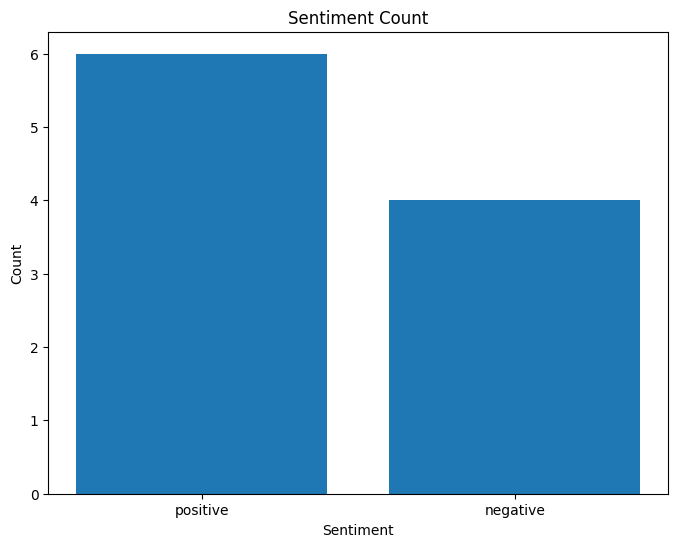

In [32]:
#visualization-sentiment count
sentiment_counts=df['sentiment'].value_counts()
plt.figure(figsize=(8,6))
plt.bar(sentiment_counts.index,sentiment_counts.values)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Count')
plt.show()

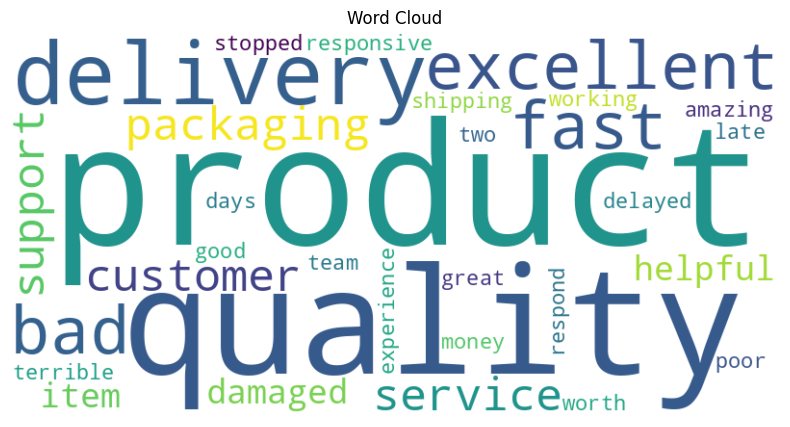

In [36]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud as word_cloud
word_cloud=word_cloud(width=800,height=400,background_color='white')
word_cloud.generate(all_words)
plt.figure(figsize=(10, 5))
plt.imshow(word_cloud,interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud')
plt.show()